# 4. Simulation statistics

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
from scipy.stats import binned_statistic
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.ndimage import median_filter
from matplotlib import patches
from matplotlib.ticker import FuncFormatter

# PlatoSim extra
import natsort
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.mocka      as mk
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [5]:
# Define paths used throughout
path = f'/lhome/nicholas/software/workdir/mocka/simulations/mocka'
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
vdir = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/data_varsim'

---
## Quick-look for simulations
---

In [6]:
star = 'DSCT'
pathx = f'{path}/{star}/clean'
patha = f'{path}/{star}/affogato'
pathc = f'{path}/{star}/cortado'
pathd = f'{path}/{star}/doppio'
pathv = f'{path}/{star}/varsource'

<IPython.core.display.Javascript object>


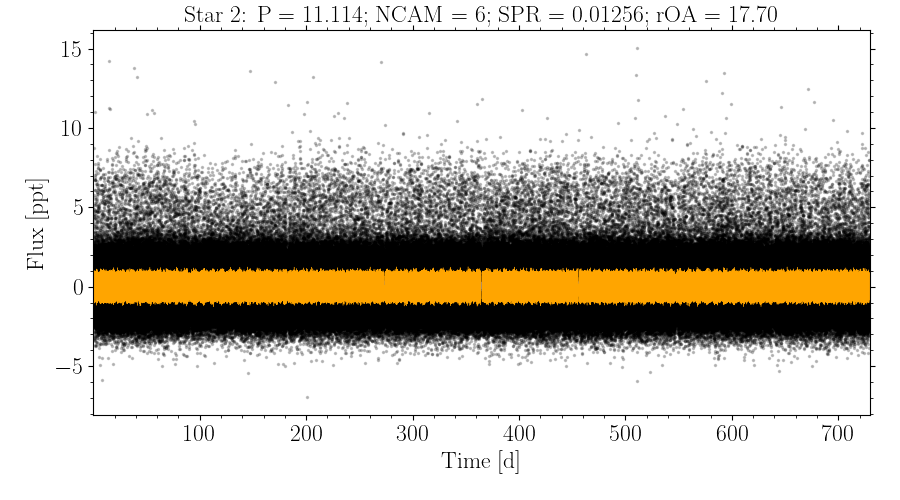

In [9]:
# Choose simulation
idir = patha
starID = f'{2}'.zfill(9)

# Fetch final ligth curve
lc = LightCurve(f'{idir}/lightcurve/lc_{starID}.ftr', mode="final")
df = lc.data()

# Load sim table
dt = pd.read_feather(f'{idir}/table/table_{starID}.ftr')

# Power
if star in ['GDOR', 'SPB']:
    power = 2.2
else:
    power = 1.0

# Create varsource from pulsations
dx = pd.read_feather(f'{pathv}/pulsations/pulsations_{starID}_001.ftr')
dv = pd.DataFrame()
dv['time'] = df.time / 86400
dv['dmag'] = ns.timeSeriesFromFourier(dv.time, dx.freq, dx.ampl, dx.phase, power=power)
dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e3

# PLOT FINAL LIGHT CURVE
fig, ax = lc.plot(flux_unit='ppt', median_filter=1, legend=False, figsize=(9,5))
ax.plot(dv.time, dv.flux, '-', c='orange', lw=0.3)
ax.set_title(f'Star {int(starID)}: P = {dt.mag[0]:.3f}; NCAM = {int(dt.shape[0]/8)}; ' + 
             f'SPR = {dt.SPR.mean():.5f}; rOA = {dt.rOA.mean():.2f}');

---
## Simulation statistics
---

In [77]:
def fetch_contaminants(path, star='GDOR', batch='affogato', old=False):
    """Function to fetch the star IDs that has a SPR > 0.
    """
    files_modes = natsort.natsorted(glob.glob(f'{path}/{star}/{batch}/table/*'))
    names_stars = [Path(files_modes[i]).stem[6:] for i in range(len(files_modes))]
    path_table  = f'{path}/{star}/{batch}/table'
    
    ids = []
    for i in tqdm(names_stars, bar_format=ut.tqdmBar()):
        dt = pd.read_feather(f'{path_table}/table_{i}.ftr') 
        if dt.SPR.iloc[0] > 0:
            ids.append(int(i))
    
    # Save and return IDs
    ids = np.array(ids)
    print(f'Number of {star} stars contaminated: {len(ids)}')
    np.savetxt(f'{path}/../../slurm/cluster_varlist_{star}.txt', ids, fmt=['%i'], header='ID')
    return ids

def fetch_table(path, star='GDOR', batch='finals_affogato', old=False):
    
    df0 = pd.DataFrame()
    files = natsort.natsorted(glob.glob(f'{path}/{star}/{batch}/table/*'))
    
    for f in tqdm(files, bar_format=ut.tqdmBar()):
        dx = pd.read_feather(f)
        df1 = pd.DataFrame({
            'ID': [dx.ID.iloc[0]],
            'gaiaDR3': [dx.gaiaDR3.iloc[0]],
            'ra': [dx.ra.iloc[0]],
            'dec': [dx.dec.iloc[0]],
            'Pmag': [dx.mag.iloc[0]],
            'rOA': [dx.rOA.mean()],
            'SPR': [dx.SPR.mean()],
            'ncon': [dx.ncon.iloc[0]],
            'ncam': [int(dx.shape[0]/8)]})
        df0 = pd.concat([df0, df1])
        
    return df0.sort_values(by=['ncam', 'Pmag']).dropna()

def plot_ncam_hist(df, title=None):
    # Total number of stars after cuts
    fig, ax = plt.subplots(1,1, figsize=(8,5))
    order = df.ncam.unique()
    nstar = df.shape[0]
    df.ncam.value_counts().loc[order].plot.bar(rot=45)
    for p,i in zip(ax.patches, range(1, df.shape[0]+1)):
        if i in [6, 12, 18, 24]:
            dx = 0.97
        else:
            dx = 1
        ax.annotate(str(p.get_height()), (p.get_x()*dx, p.get_height()*1.1))
    if title is not None: ax.set_title(title)
    ax.set_xlabel(r'N-CAM visibility, $n_{\rm CAM}$')
    ax.set_ylabel('Star count')
    ax.set_yscale('log')
    ax.set_ylim(0, nstar/2)
    plt.tight_layout()
    plt.minorticks_off()
    plt.show()

### $\gamma$ Doradus 

In [ ]:
# da_gdor = mk.fetch_all_modes(path, star='GDOR', batch='affogato')
# lcs = LightCurve

dx = do_spb
dx0 = dx.sort_values(by=['ncam', 'Pmag']).dropna()

### SPB stars

In [73]:
ids = fetch_contaminants(path, star='SPB', batch='affogato')

100%|██████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 942.23it/s]         

Number of SPB stars contaminated: 2957


100%|██████████████████████████████████████████████████| 4000/4000 [00:08<00:00, 447.22it/s]         


<IPython.core.display.Javascript object>


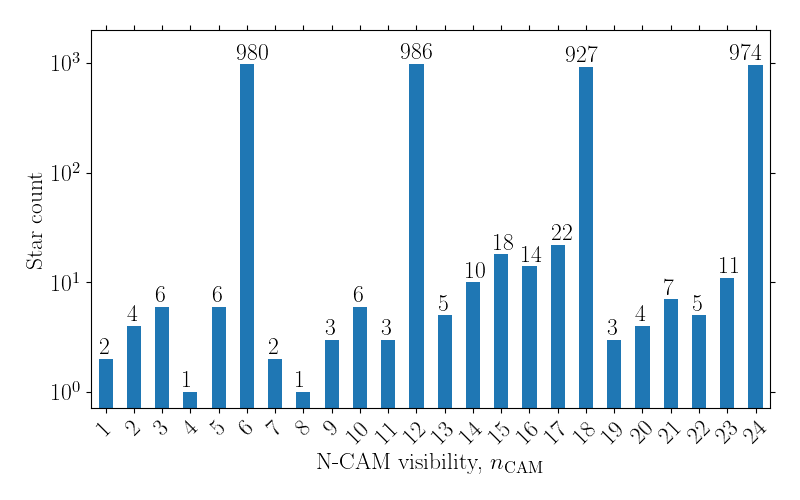

In [74]:
df = fetch_table(path, star='SPB', batch='affogato')
plot_ncam_hist(df)
# Save figure for referee
# fig.savefig(f'{fdir}/referee_historgram_starcount.png', bbox_inches='tight', dpi=200)

### $\delta$ Scuti

In [75]:
ids = fetch_contaminants(path, star='DSCT', batch='affogato')

100%|██████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 936.47it/s]         

Number of DSCT stars contaminated: 2888


100%|██████████████████████████████████████████████████| 4000/4000 [00:08<00:00, 461.33it/s]         


<IPython.core.display.Javascript object>


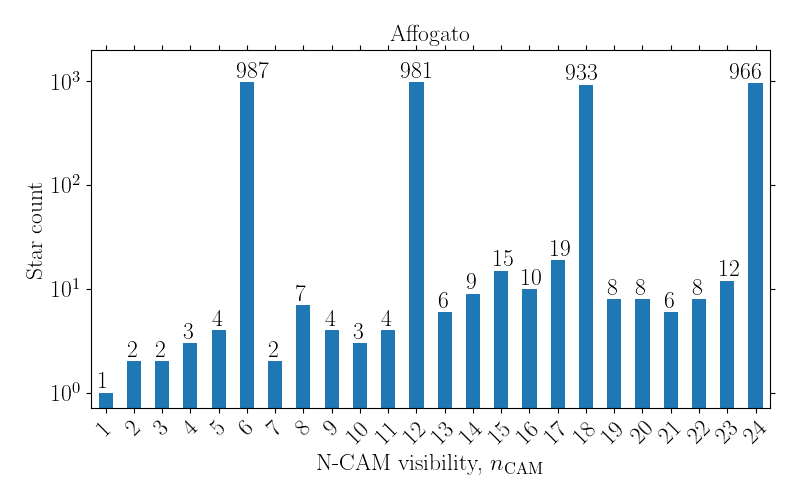

In [79]:
df = fetch_table(path, star='DSCT', batch='affogato')
plot_ncam_hist(df, title='Affogato')

### $\beta$ Cephei